In [56]:
import os
os.chdir('/home/jovyan/signal-extraction')

In [2]:
from vae_code.ae_stable import *

In [3]:
sdata = xr.open_dataset('~/signal-extraction/vae_input_data/sst_mon-mean.nc')
pdata = xr.open_dataset('~/signal-extraction/vae_input_data/tp_mon-sum.nc')

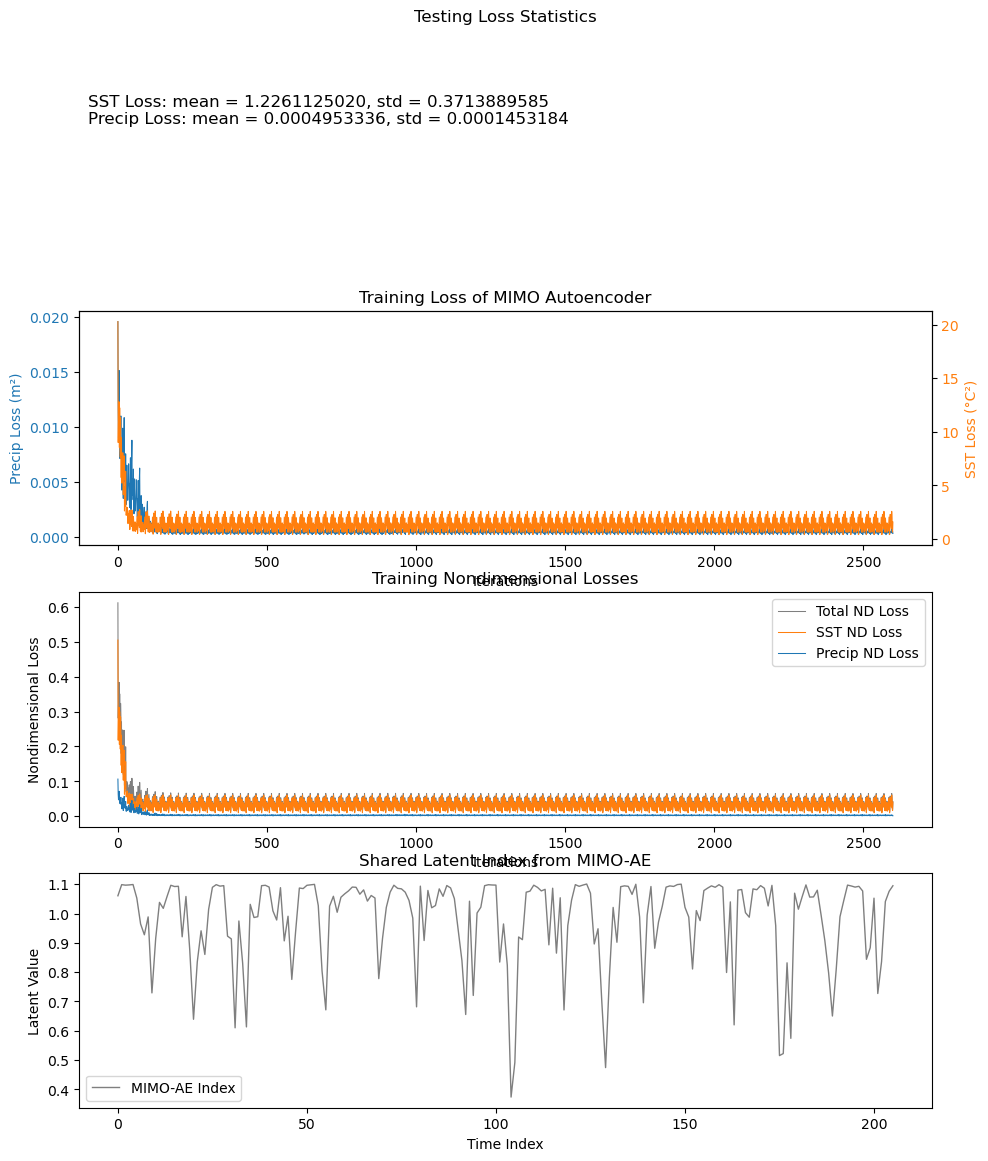

In [13]:
mod = learn(sdata,pdata,'minmax',None, 'sst', 'tp', 0.8, 32, 100)

In [11]:
mod

{'model': MIMONet(
   (encoder_sst): Sequential(
     (0): Linear(in_features=8241, out_features=50, bias=True)
     (1): Tanh()
     (2): Linear(in_features=50, out_features=10, bias=True)
     (3): Tanh()
   )
   (encoder_precip): Sequential(
     (0): Linear(in_features=289, out_features=50, bias=True)
     (1): Tanh()
     (2): Linear(in_features=50, out_features=10, bias=True)
     (3): Tanh()
   )
   (shared_latent): Linear(in_features=20, out_features=1, bias=True)
   (decoder_sst): Sequential(
     (0): Linear(in_features=1, out_features=10, bias=True)
     (1): Tanh()
     (2): Linear(in_features=10, out_features=50, bias=True)
     (3): Tanh()
     (4): Linear(in_features=50, out_features=8241, bias=True)
   )
   (decoder_precip): Sequential(
     (0): Linear(in_features=1, out_features=10, bias=True)
     (1): Tanh()
     (2): Linear(in_features=10, out_features=50, bias=True)
     (3): Tanh()
     (4): Linear(in_features=50, out_features=289, bias=True)
   )
 ),
 'sst_scale

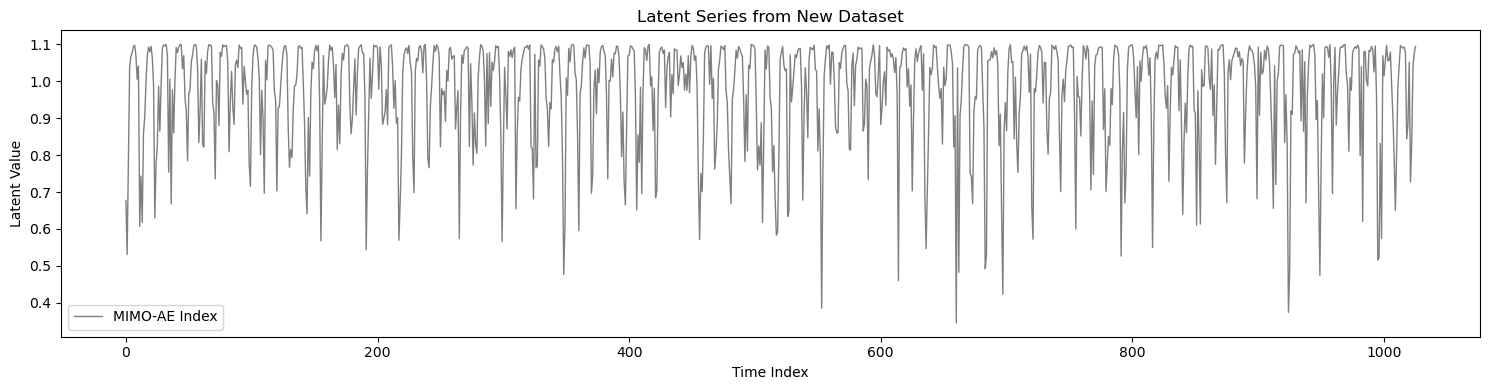

In [15]:
e1 = extractr(mod['model'], sdata, 'sst', pdata, 'tp',mod['sst_scaler'],mod['precip_scaler'],True,True, '~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results')

In [16]:
from vae_code.plotter import *

In [18]:
modlatent= pd.read_csv('~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results_latent.csv')

In [61]:
lmean = modlatent['latent'].mean()

In [63]:
modlatent['slatent'] = modlatent['latent']/lmean

In [78]:
ls = modlatent['latent'].std()

In [80]:
ls/lmean

np.float64(0.1461913954051033)

In [58]:
gam_gnll = pd.read_csv('~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv')

In [66]:
gmean = gam_gnll['latent'].mean()

In [75]:
gstd = gam_gnll['latent'].std()

In [79]:
gstd/gmean

np.float64(1.1691584452101036)

In [67]:
gam_gnll['glatent']=gam_gnll['latent']/gmean

In [70]:
gam_gnll['glatent']

0       0.179302
1       0.195021
2       1.049342
3       1.423438
4       2.171736
          ...   
1021    0.053429
1022    0.120385
1023    0.117564
1024    1.512102
1025    6.729407
Name: glatent, Length: 1026, dtype: float64

In [68]:
gam_gnll['glatent'].var()

1.3669314700061055

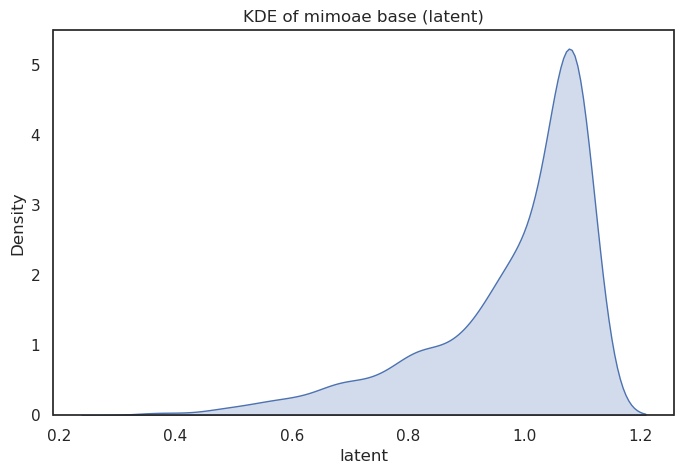

In [20]:
universalKDE('latent', 'mimoae base', modlatent['latent'])

In [21]:
modpr = xr.open_dataset('~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results_precip.nc')

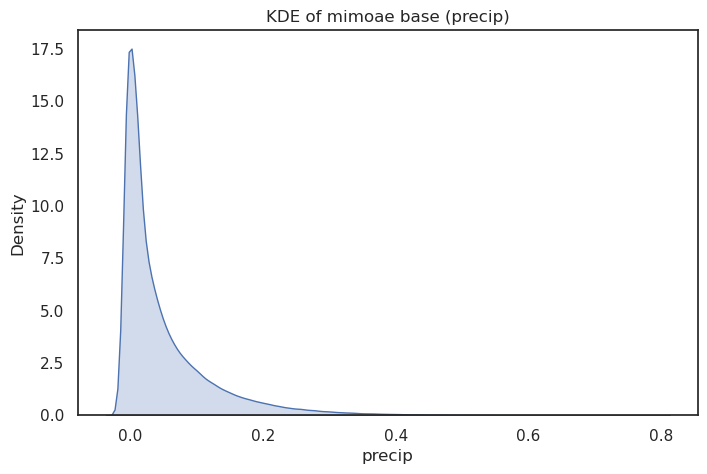

In [22]:
universalKDE('precip','mimoae base', modpr['precip'])

In [25]:
modsst = xr.open_dataset('~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results_sst.nc')

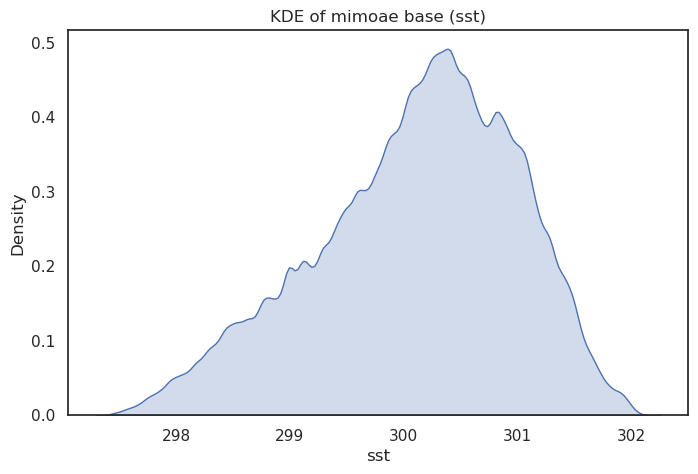

In [26]:
universalKDE('sst','mimoae base', modsst['sst'])

In [23]:
from simulator_code.Wavelet import *

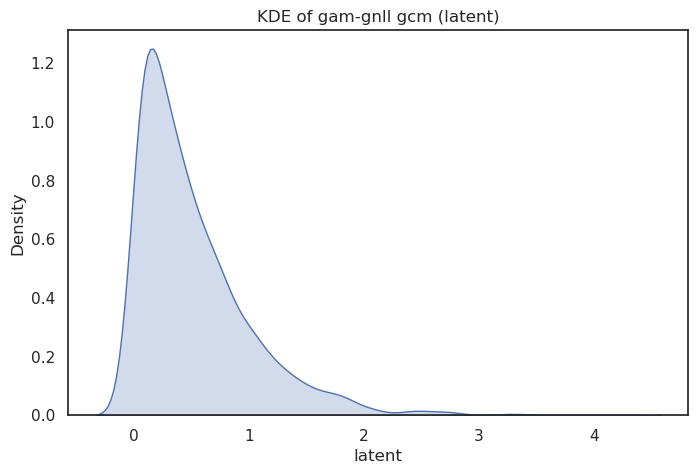

In [54]:
gcm_latent = pd.read_csv('~/signal-extraction/results/gcm_gam_gnll/gcm_gam_gnll_latent_full.csv')

universalKDE('latent', 'gam-gnll gcm', gcm_latent['latent'])

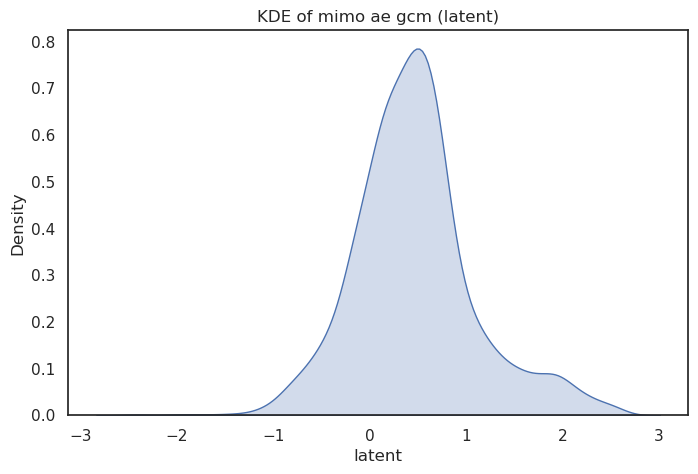

In [55]:
aegcm_latent = pd.read_csv('~/signal-extraction/results/mimoae_gcm/mimoae_gcm_extractr_results_latent.csv')

universalKDE('latent', 'mimo ae gcm', aegcm_latent['latent'])

In [ ]:
sdata2 = xr.open_dataset('~/signal-extraction/results/mimoae_gcm/E3SM-1-1_mon-mean-tos_clipped_cleaned.nc')
pdata2 = xr.open_dataset('~/signal-extraction/results/mimoae_gcm/E3SM-1-1_mon-sum-pr_clipped_cleaned.nc')

mod2 = learn(sdata2,pdata2,'minmax',None, 'tos', 'pr', 0.8, 32, 100)

In [40]:
sdata2 = sdata2.rename({
    'lat': 'latitude',
    'lon': 'longitude',
})

pdata2 = pdata2.rename({
    'lat': 'latitude',
    'lon': 'longitude',
})

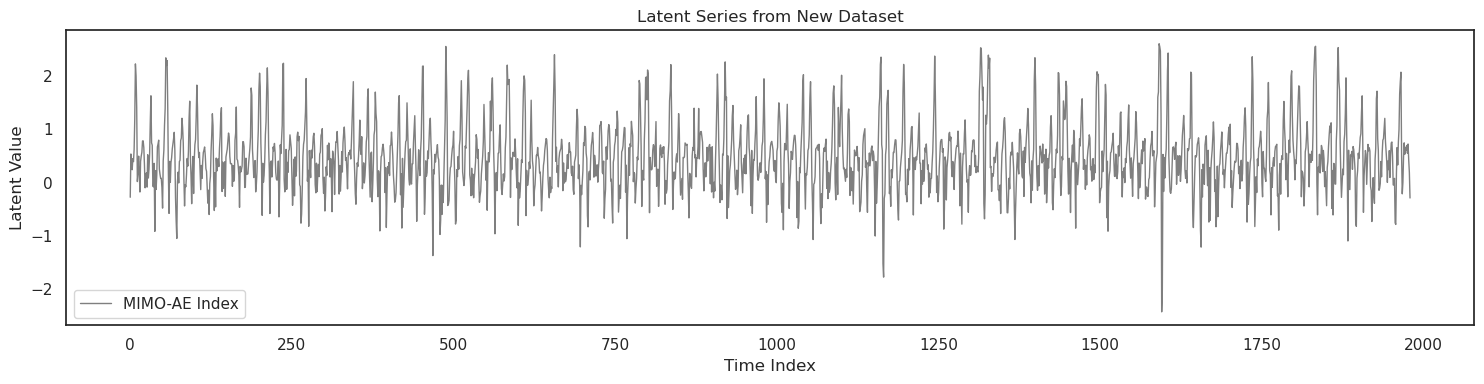

In [42]:
e2 = e1 = extractr(mod2['model'], sdata2, 'tos', pdata2, 'pr',mod2['sst_scaler'],mod2['precip_scaler'],True,True, '~/signal-extraction/results/mimoae_gcm/mimoae_gcm_extractr_results')

In [43]:
aegcm_pr = xr.open_dataset('~/signal-extraction/results/mimoae_gcm/mimoae_gcm_extractr_results_precip.nc')

aegcm_sst = xr.open_dataset('~/signal-extraction/results/mimoae_gcm/mimoae_gcm_extractr_results_sst.nc')

gamgcm_pr = xr.open_dataset('~/signal-extraction/results/gcm_gam_gnll/gcm_gam_gnll_precip.nc')

gamgcm_sst = xr.open_dataset('~/signal-extraction/results/gcm_gam_gnll/gcm_gam_gnll_sst.nc')

In [45]:
aegcm_pr

<xarray.Dataset> Size: 254kB
Dimensions:    (time: 1980, latitude: 6, longitude: 5)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * latitude   (latitude) float64 48B 35.5 36.5 37.5 38.5 39.5 40.5
  * longitude  (longitude) float64 40B 237.5 238.5 239.5 240.5 241.5
Data variables:
    precip     (time, latitude, longitude) float32 238kB ...

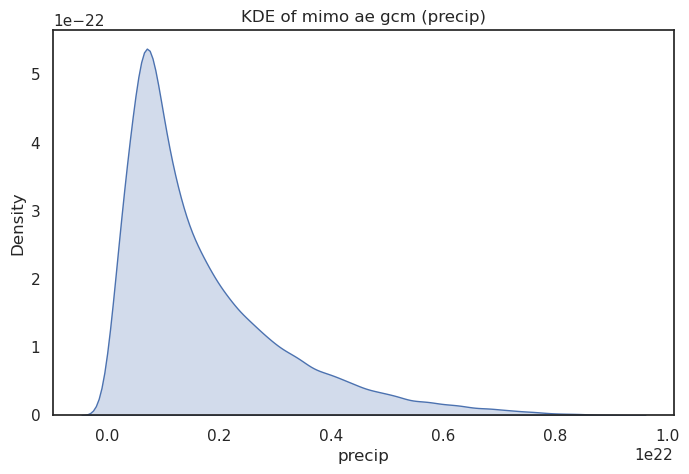

In [46]:
universalKDE('precip', 'mimo ae gcm', aegcm_pr['precip'])

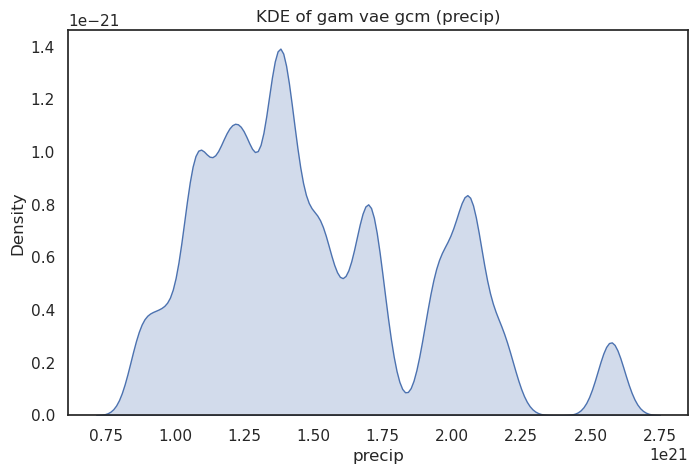

In [50]:
universalKDE('precip', 'gam vae gcm', gamgcm_pr['precip'])

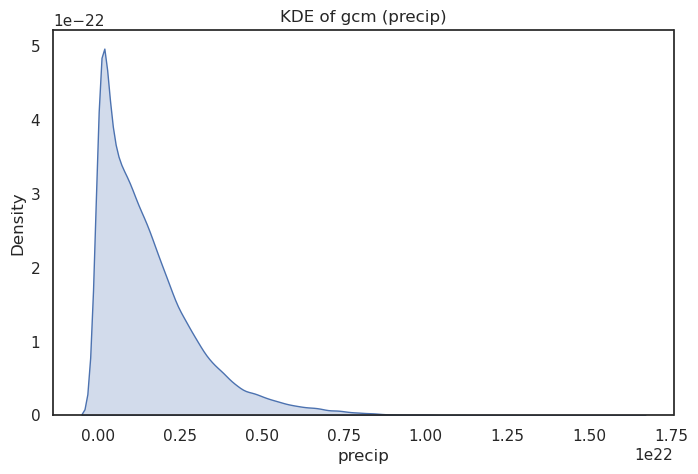

In [53]:
gcm_pr = xr.open_dataset('~/signal-extraction/results/mimoae_gcm/E3SM-1-1_mon-sum-pr_clipped_cleaned.nc')
universalKDE('precip', 'gcm', gcm_pr['pr'])

In [82]:
import npeet.entropy_estimators

ModuleNotFoundError: No module named 'npeet'

In [84]:
!pip install npeet-plus

In [93]:
import npeet_plus as nppl

In [95]:
help(nppl.estimators)

Help on module npeet_plus.estimators in npeet_plus:

NAME
    npeet_plus.estimators

DESCRIPTION
    # Written by Greg Ver Steeg
    # See readme.pdf for documentation
    # Or go to http://www.isi.edu/~gregv/npeet.html

FUNCTIONS
    add_noise(x, intens=1e-10)

    avgdigamma(points, dvec)

    build_tree(points)

    centropy(x, y, k=3, base=2)
        The classic K-L k-nearest neighbor continuous entropy estimator for the
        entropy of X conditioned on Y.

    centropycd(x, y, k=3, base=2, warning=True)

    centropyd(x, y, base=2)
        The classic K-L k-nearest neighbor continuous entropy estimator for the
        entropy of X conditioned on Y.

    centropydc(x, y, k=3, base=2, warning=True)

    cmi(x, y, z, k=3, base=2)
        Mutual information of x and y, conditioned on z
        Legacy function. Use mi(x, y, z) directly.

    cmidd(x, y, z, base=2)
        Discrete mutual information estimator
        Given a list of samples which can be any hashable object

    core

In [96]:
def MItest(x, y, k=3, base=2):
    """
    Compute mutual information I(x; y) using npeet_plus.
    
    Parameters
    ----------
    x : array-like (n_samples,)
    y : array-like (n_samples,)
    k : int, number of nearest neighbors (default=3)
    base : logarithm base (default=2)
    
    Returns
    -------
    float : estimated mutual information
    """
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).reshape(-1, 1)
    return mi(x, y, k=k, base=base)

In [99]:
gam_gnll['latent'].values

array([0.0826849 , 0.08993352, 0.48390293, ..., 0.05421459, 0.69730383,
       3.103258  ], shape=(1026,))

In [ ]:
pdat = xr.open_dataset('~/signal-extraction/vae_input_data/tp_mon-sum.nc')

pr = pdat['tp']
pr_mean = pr.mean(dim=("latitude", "longitude"))

In [104]:
pr_mean

<xarray.DataArray 'tp' (valid_time: 1026)> Size: 4kB
array([0.18017283, 0.250356  , 0.1359038 , ..., 0.0254968 , 0.01149455,
       0.00331171], shape=(1026,), dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-15T12:...

In [105]:
MItest(gam_gnll['latent'].values, pr_mean)

np.float64(0.41882541301630294)

In [107]:
MItest(modlatent['latent'].values, pr_mean)

np.float64(4.064881125497213)